In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
import statsmodels.formula.api as smf
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import altair as alt

In [2]:
kc = pd.read_csv('kc_house_data.csv')

In [3]:
kc['date'] = pd.to_datetime(kc.date)

In [4]:
sqft_to_sqmeters = 0.09290303997

In [5]:
kc = kc.astype({'sqft_living': float, 'sqft_lot': float, 
                'sqft_above': float, 'sqft_basement': float,
                'sqft_living15': float, 'sqft_lot15': float})

In [6]:
kc.loc[:,['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']] =\
kc.loc[:,['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15']] * sqft_to_sqmeters

In [7]:
kc.columns = ['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqm_living',
       'sqm_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqm_above', 'sqm_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqm_living15', 'sqm_lot15']

In [8]:
kc = kc.loc[:, ['id', 'date', 'price', 
            'floors', 'bedrooms', 'bathrooms', 
            'yr_built', 'yr_renovated',
            'waterfront', 'view', 'condition', 'grade', 
            'sqm_living', 'sqm_lot', 
            'sqm_above', 'sqm_basement',
            'sqm_living15', 'sqm_lot15',
            'lat', 'long']]

In [9]:
kc.loc[kc.yr_renovated == 0, 'yr_renovated'] = np.nan

In [10]:
kc.loc[kc.sqm_basement == 0, 'sqm_basement'] = np.nan

##### Altair renderers

In [11]:
alt.data_transformers.disable_max_rows()

DataTransformerRegistry.enable('default')

In [12]:
alt.renderers.active

'default'

In [13]:
alt.renderers.enable('default')
# https://altair-viz.github.io/user_guide/display_frontends.html

RendererRegistry.enable('default')

##### Plotly configuration

In [14]:
base = pio.templates["simple_white"]
custom_template = base.layout.template

custom_template.layout.update(
    margin=dict(l=40, r=0, t=20, b=40),
    xaxis=dict(
        title_standoff=0,
        ticks="inside",
        showgrid=True
    ),
    yaxis=dict(
        title_standoff=0,
        ticks="inside",
        showgrid=True
    )
)

pio.templates["tight"] = custom_template
pio.templates.default = "tight"

In [31]:
pio.renderers

Renderers configuration
-----------------------
    Default renderer: 'vscode'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']

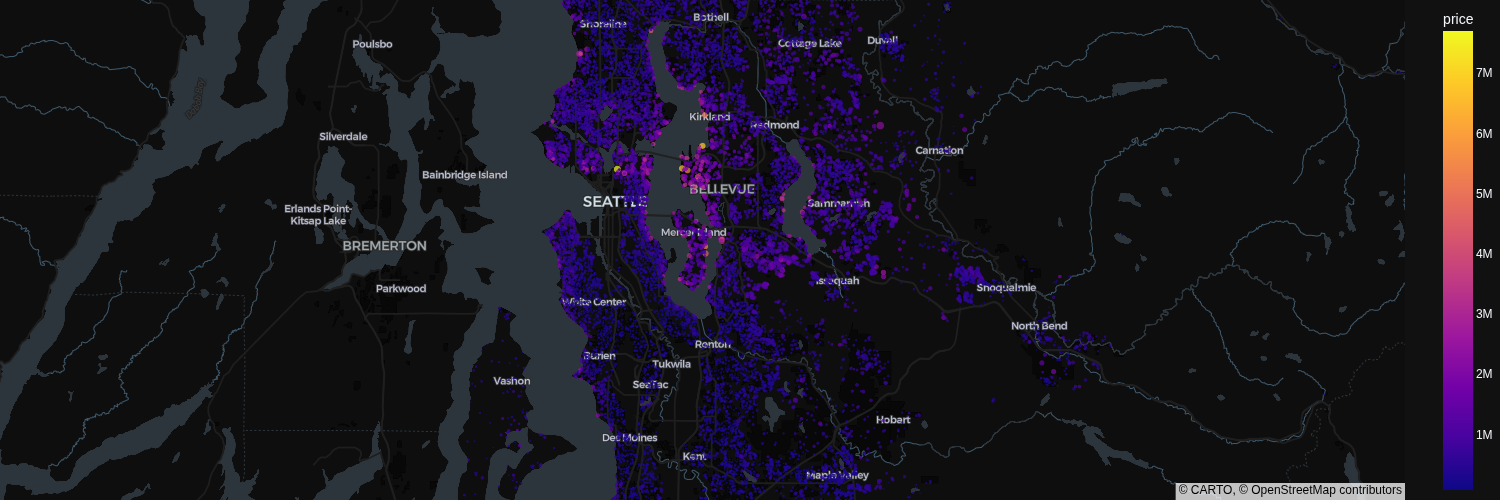

In [51]:
px.scatter_map(kc, lat='lat', lon='long', size='sqm_living', color='price', 
               template='plotly_dark', map_style='carto-darkmatter', 
               color_continuous_scale='plasma', size_max=6, zoom=9.1, 
               ).update_layout(margin=dict(l=0,r=0,b=0,t=0)
               ).show(renderer='png', width=1500, height=500)

# Histograms

In [16]:
# px.histogram(kc, ['sqm_above', 'sqm_basement','sqm_living'],
#             color_discrete_sequence=px.colors.qualitative.T10,
#             template='simple_white', opacity=0.3,
#             range_y=[0,400], 
# ).update_traces(xbins_start=0, xbins_end=400, xbins_size=2,
#                 marker_line_width=0, marker_cornerradius=10
# ).update_layout(barmode='overlay',
#                 margin=dict(l=0,r=0,b=0,t=0), height = 330
# ).update_xaxes(title_standoff=0, ticks='inside',  showgrid=True, title_text='square meters'
# ).update_yaxes(title_standoff=0, ticks='inside',  showgrid=True)

In [17]:
# alt.Chart(kc, width=1400).transform_fold(
#     ['sqm_living','sqm_above', 'sqm_basement'],
#     as_=['type', 'area']
# ).mark_area(
#     clip=True,
#     opacity=0.3,
#     # line=True,
#     interpolate='step-after',
# ).encode(
#     alt.X('area:Q').bin(extent=[0,400], step=2),
#     alt.Y('count()').stack(None).scale(domainMax=500),
#     alt.Color('type:N'),
# )
#     # for mark_bar
#     # cornerRadiusEnd=10,
#     # binSpacing=0,

In [18]:
# sns.set(rc={"figure.figsize":(16,4)})
# sns.set_style('white')
# sns.histplot(kc[['sqm_above', 'sqm_basement', 'sqm_living']],
#              binrange=(0,400), binwidth=2, palette=['#1f77b4', '#ff7f0e', '#d62728'],
#              kde=False, kde_kws={'clip':(0,400)},
#              multiple='layer', element='step', alpha=0.3, linewidth=0)

# Scatterplots

In [19]:
# Plotly themes: 
#     'ggplot2', 'seaborn', 'plotly', None    # - ggplot2 = seaborn, plotly = None
#     'simple_white',                         # - just white, no grid, black axes
#     'plotly_white',                         # - white, thin grids and axes
#     'presentation',                         # - the same but bigger fonts, bordered legend
#     'xgridoff','ygridoff', 'gridon',        # - = plotly white
#     'plotly_dark']                          # - inverted plotly white

In [20]:
# px.scatter(kc.loc[kc.price < 10**6], x='date', y='price', color='bedrooms',
#            template='simple_white', opacity=0.4, width=1600, height=500,
#            range_x=(['2014-05','2015-06']), range_y=[0,1*10**6],
#            range_color=([0,5]),
#            color_continuous_scale=px.colors.sequential.Inferno,
# ).update_traces(marker_size=14
# ).update_layout(margin=dict(l=50, r=0, t=20, b=0)
# ).update_xaxes(title_standoff=0, ticks='inside', showgrid=True,
# ).update_yaxes(title_standoff=0, ticks='inside', showgrid=True)

In [21]:
# alt.Chart(kc.loc[kc.price<10**6], width=1400, height=500).mark_circle(tooltip=True,
#     size=200, opacity=0.4, clip=True).encode(
#     alt.X('date', type='temporal').axis(grid=False),
#     alt.Y('price', type='quantitative').axis(grid=False),
#     alt.Color(field ='bedrooms', type='quantitative').scale(
#         domain=[0,5], scheme='inferno')).properties(background='white')

In [22]:
# alt.renderers.active

In [23]:
# .display(renderer='svg')
# jupyter - 6.7s (less blurry)
# default - 0.5s (blurry if os scaling!= monitor scaling)
# svg - 1s (no blur)
# png - 2s (less blurry, no white background needed)
# mimetype - 0.5s (less blurry, needs .properties(background='white')
# seaborn is also blurry when scalings differ

In [24]:
# sns.set(rc={"figure.figsize":(14,7)})
# sns.set_style('white')
# sns.scatterplot(kc.loc[kc.price<10**6], x='date', y='price', hue='bedrooms',
#                 palette='inferno', s=100, alpha=0.4, hue_norm=(0,5), linewidth = 0)
# plt.legend(loc=[1,0], markerscale=1)

# Scatter Matrices

In [25]:
# jupyter - 9.4s
# jupyter (, offline=True) - 9.3s
# svg - 9.6s
# png - 23s
# default(html) - 0.5s (blurry when os scaling different from monitor)
# mimetype - 0.5s (png, transparent background, needs .properties(background='white')

In [26]:
# alt.Chart(kc).mark_circle(
#     size=20, opacity=0.3, tooltip=True
# ).encode(
#     alt.X(alt.repeat("column"), type='quantitative').scale(zero=False),
#     alt.Y(alt.repeat("row"), type='quantitative').scale(zero=False),
#     alt.Color('condition:N').scale(scheme='tableau10')
# ).properties(
#     width=225,
#     height=225
# ).repeat(
#     row=['price', 'grade', 'sqm_living', 'sqm_lot', 'yr_built'],
#     column=['price', 'grade', 'sqm_living', 'sqm_lot', 'yr_built']
# ).configure_facet(spacing=0
# ).configure_legend(symbolOpacity=1)

In [27]:
# px.scatter_matrix(kc, dimensions=['price', 'grade', 'sqm_living', 'sqm_lot', 'yr_built'], color='condition',
#                   template='plotly_white', opacity=0.3,
#                   color_continuous_scale=px.colors.qualitative.T10[:5],
#                   height=1530, width=1530
# ).update_traces(marker_size=5.1, showlowerhalf=True
# ).update_layout(margin=dict(l=0, r=0, t=20, b=0)
# ).update_xaxes(title_standoff=0, ticks='inside'
# ).update_yaxes(title_standoff=0, ticks='inside')

In [28]:
# sns.set(rc={"figure.figsize":(18,18)})
# sns.set_theme(style="ticks")
# sns.pairplot(kc, hue="condition", vars=['price', 'grade', 'sqm_living', 'sqm_lot', 'yr_built'],
#             #  kind='reg', plot_kws={'x_ci' : None, 'scatter_kws' : {'s': 1, 'alpha' : 0.2}, 'line_kws' : {'lw': 1}},
#              kind='scatter', plot_kws={'s': 10, 'alpha': 0.2, 'linewidth' : 0},
#              palette='tab10')

# Datetime

In [29]:
# dates_limits = mpl.dates.date2num(np.datetime64(kc.date.min())) - 1,\
#                mpl.dates.date2num(np.datetime64(kc.date.max()))
# dates_range = mpl.dates.date2num(
#     pd.date_range(start=kc.date.min(), end=kc.date.max(), freq='W-MON'))

# fig, ax = plt.subplots(figsize=(18,4))
# sns.set_style('whitegrid')
# sns.histplot(kc.date, element='step', binwidth=1, alpha=0.5,
#              binrange=(dates_limits)).set_xlim(dates_limits)

# ax.xaxis.set_major_formatter(mpl.dates.DateFormatter('%d-%b-%Y'))
# ax.xaxis.set_ticks_position('top')
# plt.xticks(dates_range, rotation=90)
# plt.show()

In [30]:
# altair_plots = []
# features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']  # Explicitly define features

# for feature1 in features:
#     for feature2 in features:
#         if feature1 == feature2:
#             chart = alt.Chart(df).mark_bar().encode(
#                 x=alt.X(f"{feature1}:Q", bin=True),  # Add quantitative type
#                 y="count()",
#                 color=alt.Color("species:N")
#             )
#         else:
#             chart = alt.Chart(df).mark_circle().encode(
#                 x=alt.X(f"{feature2}:Q"),  # Add quantitative type
#                 y=alt.Y(f"{feature1}:Q"),  # Add quantitative type
#                 color=alt.Color("species:N")
#             ).interactive()
#         altair_plots.append(chart)

# altair_final_plot = alt.vconcat(*[alt.hconcat(*altair_plots[i:i+4]) for i in range(0, len(altair_plots), 4)])
# altair_final_plot = altair_final_plot.properties(title="Pairplot using Altair")
# altair_final_plot